# Predicting Road Accident Risk Project

This project aims to develop a machine learning model that accurately predicts road accident risk levels by analyzing environmental, traffic, and historical data.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSp-MN26pXrgld5kvQDYRt5M_gpg5gJIaQpxT6KKue9IK0SjBan6gFfZyPE&s=10' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")

# EDA

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
df.tail()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51
517753,517753,highway,2,0.31,45,dim,rainy,False,True,afternoon,True,True,2,0.22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [6]:
df.shape

(517754, 14)

In [7]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [8]:
df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [9]:
df.corr(numeric_only=True)

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
id,1.000000,-0.000434,0.000938,-0.000678,-0.001594,0.000554,-0.001582,-0.001567,0.000104,0.000969
num_lanes,-0.000434,1.000000,-0.020245,0.001194,-0.000498,-0.002041,0.002544,-0.001081,0.017662,-0.006003
curvature,0.000938,-0.020245,1.000000,0.008399,0.017168,0.048220,0.063931,-0.004502,0.145034,0.543946
speed_limit,-0.000678,0.001194,0.008399,1.000000,-0.004461,0.011497,0.010992,0.004392,0.031373,0.430898
road_signs_present,-0.001594,-0.000498,0.017168,-0.004461,1.000000,0.003828,-0.003813,0.002287,-0.000162,0.000629
public_road,0.000554,-0.002041,0.048220,0.011497,0.003828,1.000000,-0.007920,0.004117,-0.007026,0.031032
holiday,-0.001582,0.002544,0.063931,0.010992,-0.003813,-0.007920,1.000000,-0.001514,-0.015053,0.051129
school_season,-0.001567,-0.001081,-0.004502,0.004392,0.002287,0.004117,-0.001514,1.000000,0.003962,-0.000977
num_reported_accidents,0.000104,0.017662,0.145034,0.031373,-0.000162,-0.007026,-0.015053,0.003962,1.000000,0.213891
accident_risk,0.000969,-0.006003,0.543946,0.430898,0.000629,0.031032,0.051129,-0.000977,0.213891,1.000000


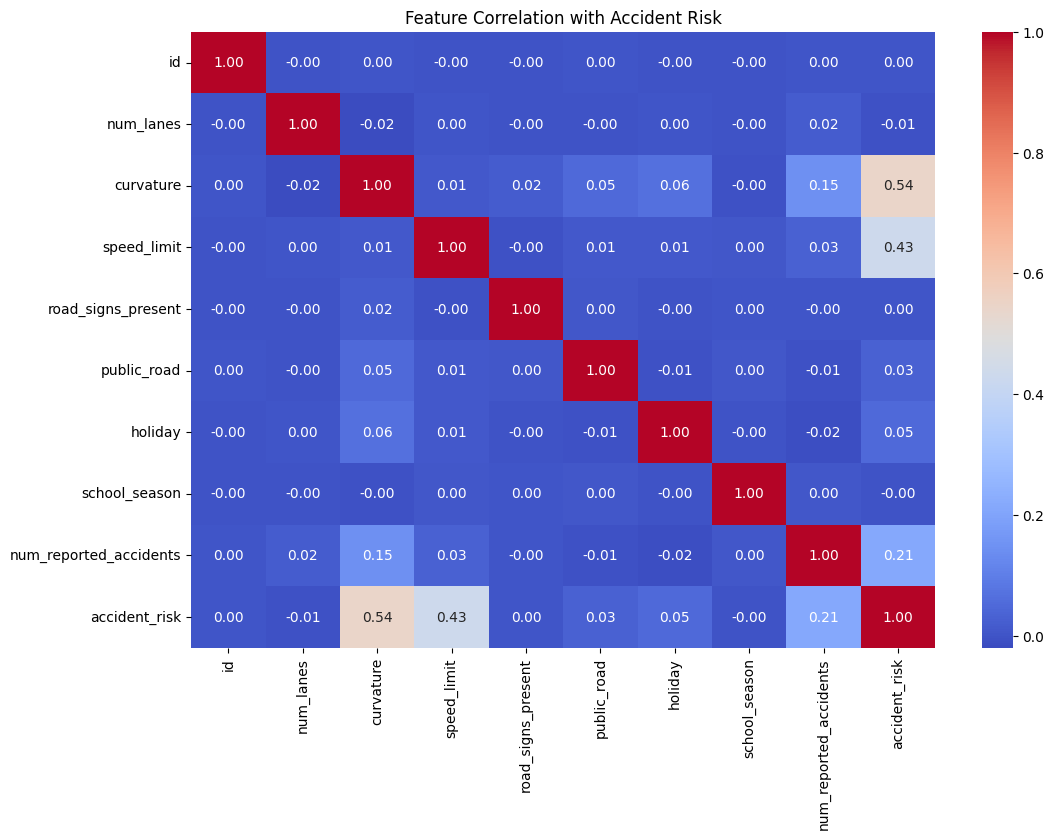

In [12]:
# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')      
plt.title("Feature Correlation with Accident Risk")      
plt.show()

In [13]:
abs(df.corr(numeric_only=True)['accident_risk'].sort_values(ascending=False))

accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
num_reported_accidents    0.213891
holiday                   0.051129
public_road               0.031032
id                        0.000969
road_signs_present        0.000629
school_season             0.000977
num_lanes                 0.006003
Name: accident_risk, dtype: float64

In [14]:
df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [15]:
df = df.drop('id', axis=1)

In [16]:
df.road_type.value_counts()

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

<Axes: xlabel='road_type', ylabel='count'>

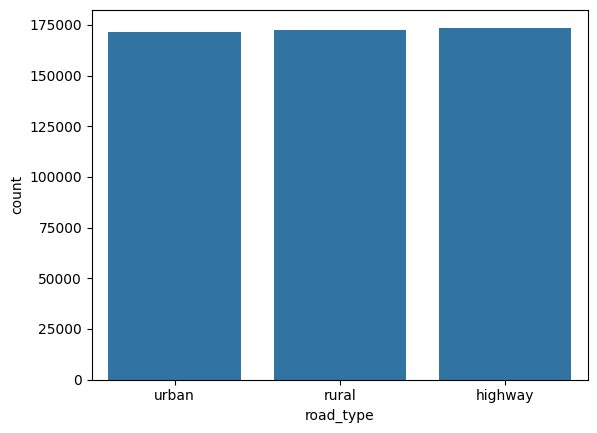

In [17]:
sns.countplot(data=df, x="road_type")

In [18]:
df.lighting.value_counts()

lighting
dim         183826
daylight    178015
night       155913
Name: count, dtype: int64

<Axes: xlabel='lighting', ylabel='count'>

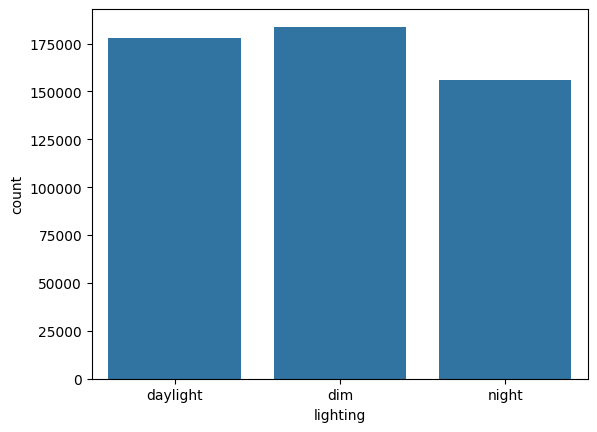

In [19]:
sns.countplot(data=df, x="lighting")

In [20]:
df.weather.value_counts()

weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

<Axes: xlabel='weather', ylabel='count'>

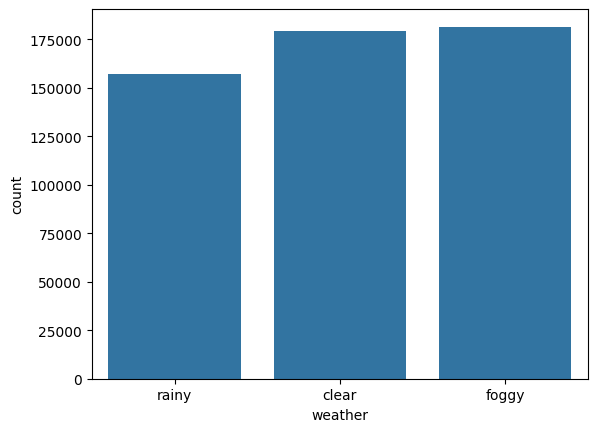

In [21]:
sns.countplot(data=df, x="weather")

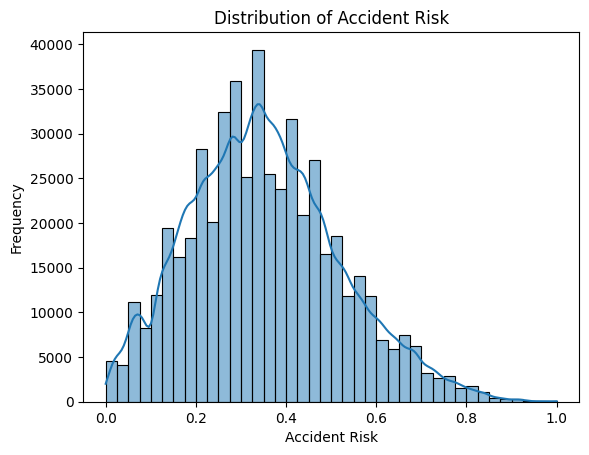

In [22]:
plt.figure()

sns.histplot(df["accident_risk"], bins=40, kde=True)

plt.title("Distribution of Accident Risk")
plt.xlabel("Accident Risk")
plt.ylabel("Frequency")

plt.show()

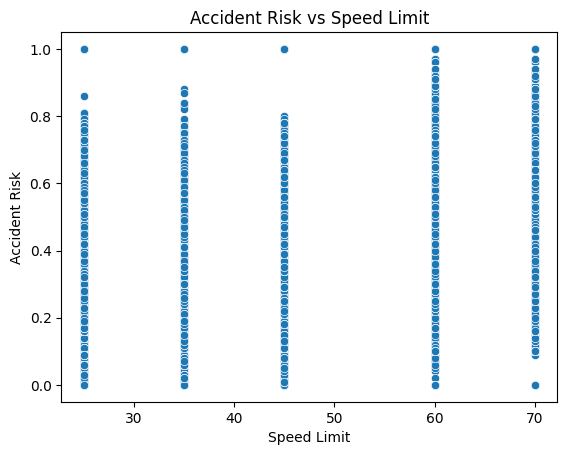

In [24]:
plt.figure()

sns.scatterplot(
    x=df["speed_limit"],
    y=df["accident_risk"]
)

plt.title("Accident Risk vs Speed Limit")
plt.xlabel("Speed Limit")
plt.ylabel("Accident Risk")

plt.show()

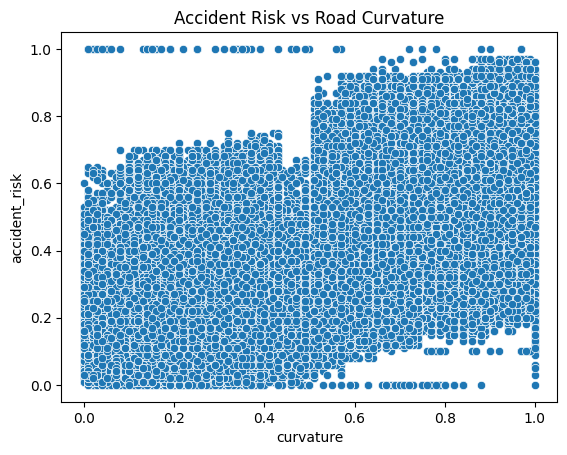

In [27]:
plt.figure()

sns.scatterplot(
    x=df["curvature"],
    y=df["accident_risk"]
)

plt.title("Accident Risk vs Road Curvature")

plt.show()

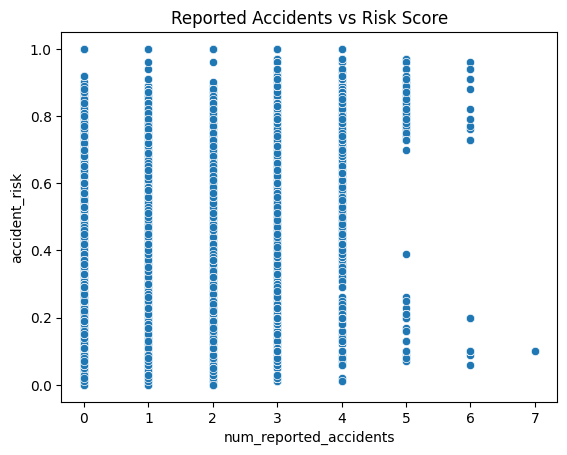

In [28]:
plt.figure()

sns.scatterplot(
    x=df["num_reported_accidents"],
    y=df["accident_risk"]
)

plt.title("Reported Accidents vs Risk Score")

plt.show()

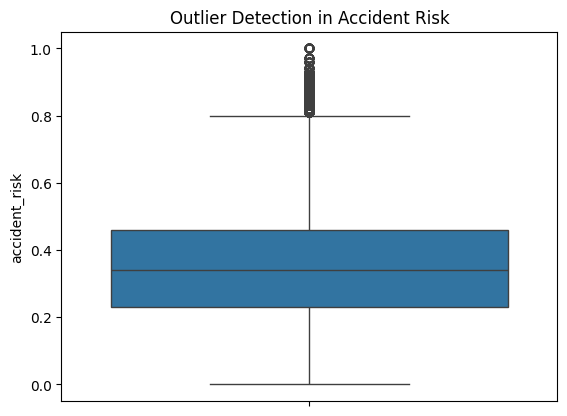

In [29]:
plt.figure()

sns.boxplot(df["accident_risk"])

plt.title("Outlier Detection in Accident Risk")

plt.show()

# Modeling

In [30]:
x= df.drop(['accident_risk'], axis=1)

In [31]:
y= df['accident_risk']

In [39]:
x=pd.get_dummies(x,drop_first=True)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [42]:
x_train.shape

(414203, 16)

In [43]:
x_test.shape

(103551, 16)

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
lr=LinearRegression()

In [46]:
model=lr.fit(x_train,y_train)

In [47]:
prediction=model.predict(x_test)

In [48]:
from sklearn.metrics import r2_score,mean_squared_error 

In [49]:
r2_score(y_test,prediction)

0.8041884067087808

In [50]:
mean_squared_error(y_test,prediction)**.5

0.07353086258983135

In [51]:
residuals= y_test-prediction

In [52]:
residuals

50309    -0.056106
95219    -0.067704
197653    0.081013
111236   -0.000314
147247    0.042657
            ...   
453214    0.035907
190565   -0.017584
357332   -0.115285
503653    0.086626
433359   -0.087795
Name: accident_risk, Length: 103551, dtype: float64

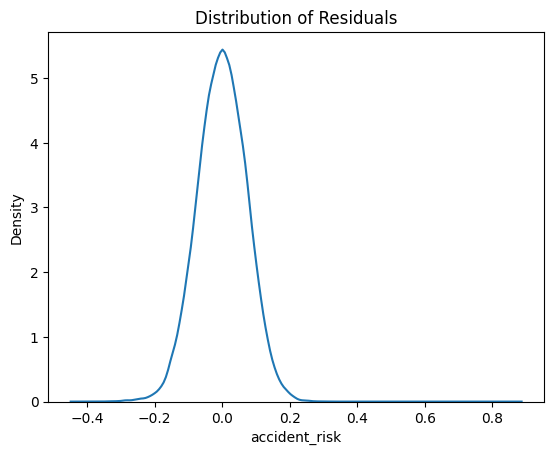

In [53]:
# If residuals is a Series or Array
sns.kdeplot(residuals)
plt.title('Distribution of Residuals')
plt.show()

In [54]:
from yellowbrick.regressor import ResidualsPlot

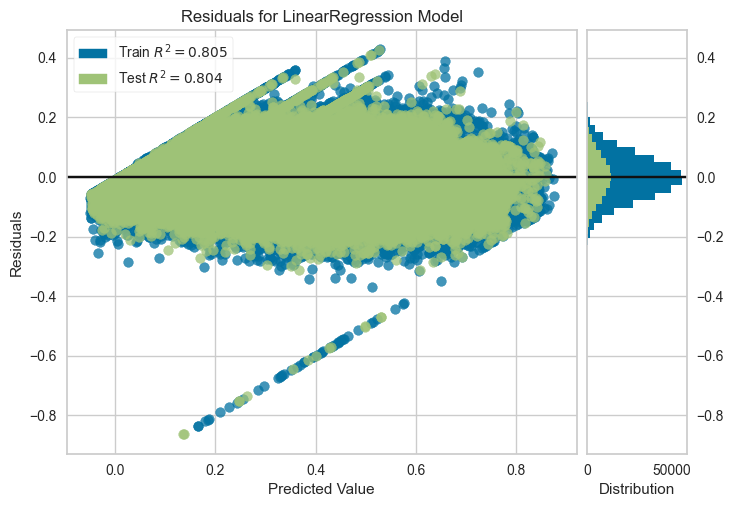

In [55]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
# pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
        # Initializing all regression models
        L = LinearRegression()
        R = Ridge()
        Lass = Lasso()
        E = ElasticNet()
        sgd = SGDRegressor()
        ETR = ExtraTreeRegressor()
        GBR = GradientBoostingRegressor()
        dt = DecisionTreeRegressor()
        xgb = XGBRegressor()
        

        algos = [L, R, Lass, E, sgd, ETR, GBR, dt, xgb]
        algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 'Gradient Boosting', 'Decision Tree', 'XGBRegressor']
        
        # Scaling features using MinMaxScaler
        x = MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

        r_squared = []
        rmse = []
        mae = []

        # Creating a dataframe to store error metrics and accuracy rates
        result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

        for algo in algos:
            # Fitting the model and making predictions
            p = algo.fit(x_train, y_train).predict(x_test)
            r_squared.append(r2_score(y_test, p))
            rmse.append(mean_squared_error(y_test, p)**.5)
            mae.append(mean_absolute_error(y_test, p))

        # Populating the result table with accuracy and error rates
        result.R_Squared = r_squared
        result.RMSE = rmse
        result.MAE = mae

        # Sorting the result table by R-Squared (accuracy) in descending order
        rtable = result.sort_values('R_Squared', ascending=False)
        return rtable

In [58]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.885049,0.056339,0.043746
Gradient Boosting,0.881910,0.057103,0.044453
Ridge,0.804188,0.073531,0.058312
Linear,0.804188,0.073531,0.058312
SGD,0.804138,0.073540,0.058320
Extra Tree,0.750624,0.082981,0.064086
Decision Tree,0.748710,0.083299,0.064243
Lasso,-0.000047,0.166173,0.132693
ElasticNet,-0.000047,0.166173,0.132693


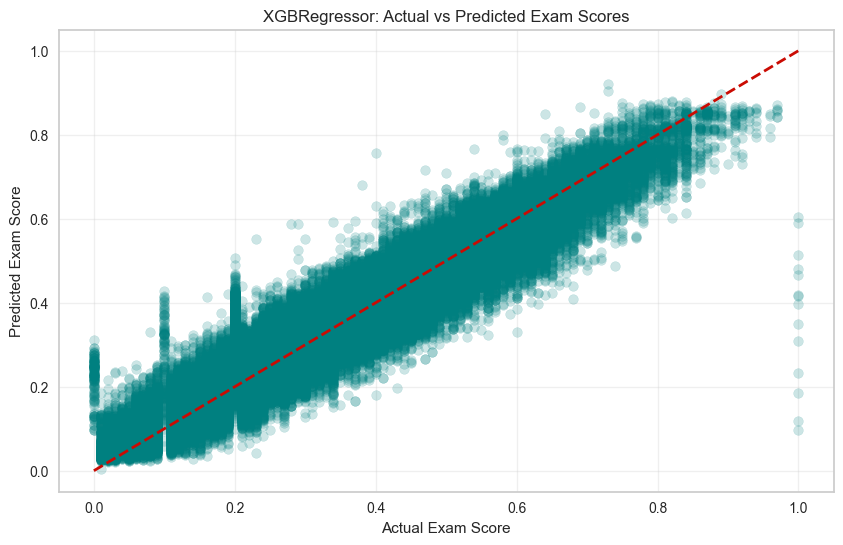

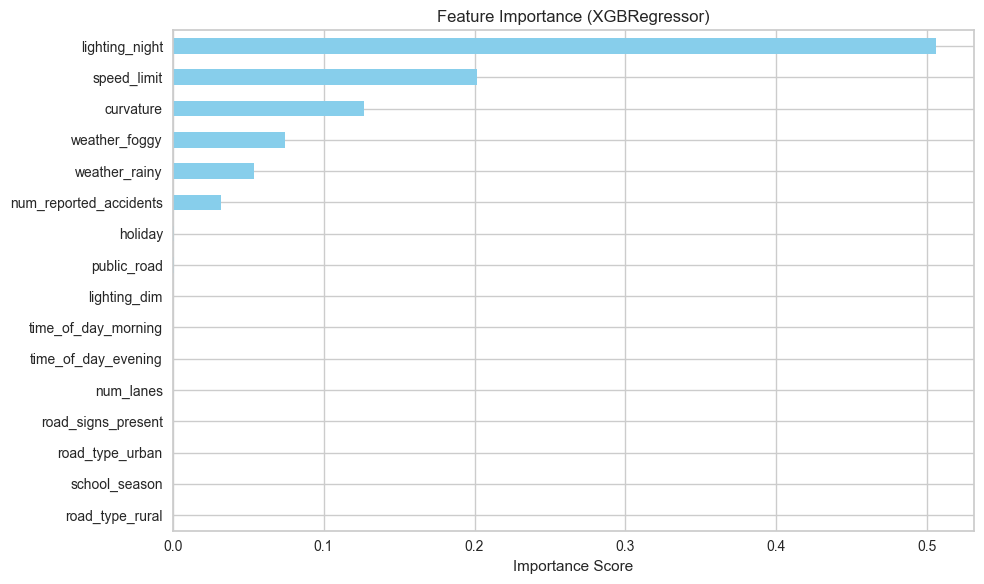

In [59]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Train the winning model (XGBRegressor)
# Using the updated 'device' parameter for Kaggle GPU
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    tree_method='hist',      # Use 'hist' for both CPU and GPU
    device='cuda',           # This is the new way to trigger GPU (replaces gpu_id/gpu_hist)
    random_state=42
)

# Fitting the model
model.fit(x_train, y_train)
prediction = model.predict(x_test)

# 2. Visualizing Prediction vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, prediction, alpha=0.2, color='teal') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('XGBRegressor: Actual vs Predicted Exam Scores')
plt.grid(alpha=0.3)
plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
# Using X.columns (ensure X is your dataframe before scaling)
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (XGBRegressor)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


This project successfully established a high-performing regression pipeline to predict road accident risk using the Kaggle Playground Series S5E10 dataset. By implementing a custom ordinal mapping strategy, we efficiently transformed categorical environmental and infrastructure data into a machine-learning-ready format while maintaining a low memory footprint. Evaluation across multiple algorithms identified the XGBRegressor as the superior model, achieving a robust  
R
2
  score of 0.885 and a competitive RMSE of 0.056. These results demonstrate that factors such as weather, lighting, and road curvature are powerful predictors of safety risk when modeled with gradient boosting. The final model and features have been serialized for deployment, providing a scalable solution for real-time risk assessment in synthetic traffic environments.

In [60]:
import joblib

# Save the model
joblib.dump(model, 'accident_risk_model.pkl')

['accident_risk_model.pkl']